In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import recall_score
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.metrics import precision_score, f1_score, confusion_matrix
from imblearn.ensemble import BalancedRandomForestClassifier

file_path_diabetes = "diabetes_prediction_dataset.csv"

df_diabetes = pd.read_csv(file_path_diabetes)

df_diabetes.head().style.set_table_styles(
    [{'selector': 'th', 'props':
     [('font-weight', 'bold'), ('background-color', '#f0f0f0')]}] ).set_properties(**{'text-align': 'center'})

df_diabetes["smoking_history"] = df_diabetes["smoking_history"].replace({"current": 1,
      "never": 0,'No Info': 0,'ever': 1,'formerly': 1,'not current': 0, 'former': 0})

df_diabetes['smoking_history'] = df_diabetes['smoking_history'].astype(int)

df_diabetes['age'] = df_diabetes['age'].astype(int)

print('Nº Total de filas y columnas:\n',df_diabetes.shape)
print(df_diabetes.head())
print(df_diabetes.info())
print(df_diabetes.describe())

Nº Total de filas y columnas:
 (100000, 9)
   gender  age  hypertension  heart_disease  smoking_history    bmi  \
0  Female   80             0              1                0  25.19   
1  Female   54             0              0                0  27.32   
2    Male   28             0              0                0  27.32   
3  Female   36             0              0                1  23.45   
4    Male   76             1              1                1  20.14   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                  140         0  
1          6.6                   80         0  
2          5.7                  158         0  
3          5.0                  155         0  
4          4.8                  155         0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               10000

C:\Users\USER\AppData\Local\Temp\ipykernel_19296\1891460361.py:18: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_diabetes["smoking_history"] = df_diabetes["smoking_history"].replace({"current": 1,


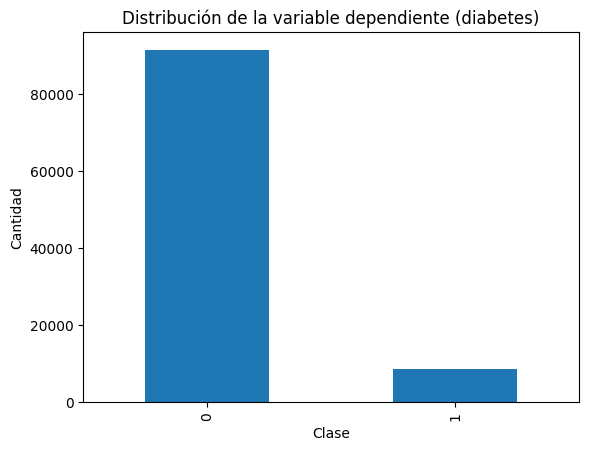

In [2]:
diabetes_colum = "diabetes"

counts = df_diabetes[diabetes_colum].value_counts()

percent = df_diabetes[diabetes_colum].value_counts(normalize=True) * 100 

balance_table = pd.DataFrame({
    "count": counts,
    "percent": percent.round(2)})

counts.plot(kind="bar")
plt.title("Distribución de la variable dependiente (diabetes)")
plt.xlabel("Clase")
plt.ylabel("Cantidad")
plt.show()

In [3]:
ratio = counts[0] / counts[1]
ratio = (f"{ratio:.2f}")
print('El dataset presenta un ratio aproximado de',(ratio),': 1 entre casos negativos y positivos de diabeticos')

El dataset presenta un ratio aproximado de 10.76 : 1 entre casos negativos y positivos de diabeticos


In [4]:
y = df_diabetes['diabetes']
x = df_diabetes[['age','bmi',
                 'hypertension',
                 'heart_disease',
                 'smoking_history',
                 'blood_glucose_level',
                 'HbA1c_level']]

In [5]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.15, random_state=42)

random_forest_model = BalancedRandomForestClassifier(random_state=42,n_estimators=300)
random_forest_model.fit(x_train, y_train)

y_pred_rf = random_forest_model.predict_proba(x_test)[:, 1]

new_threshold = 0.67

y_pred_rf_new_threshold = (y_pred_rf >= new_threshold).astype(int)

recall_rf = recall_score(y_test, y_pred_rf_new_threshold)
print(f"Recall Score con Random Forest {recall_rf}")

Recall Score con Random Forest 0.7920560747663551


Precision Score con Random Forest: 0.6951469583048531
F1-Score con Random Forest: 0.740444120859119
Matriz de Confusión con Random Forest:
[[13270   446]
 [  267  1017]]


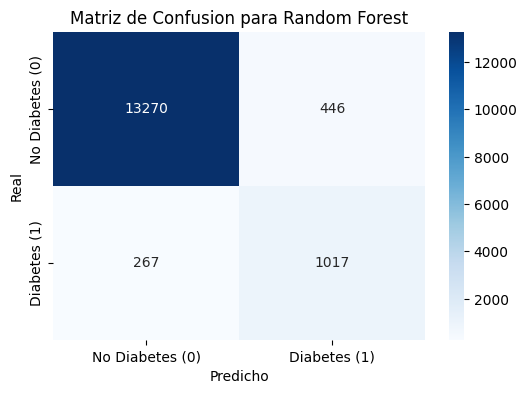

In [6]:
precision_rf = precision_score(y_test, y_pred_rf_new_threshold)
print(f"Precision Score con Random Forest: {precision_rf}")

f1_rf = f1_score(y_test, y_pred_rf_new_threshold)
print(f"F1-Score con Random Forest: {f1_rf}")

cm_rf = confusion_matrix(y_test, y_pred_rf_new_threshold)
print("Matriz de Confusión con Random Forest:")
print(cm_rf)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes (0)', 'Diabetes (1)'],
            yticklabels=['No Diabetes (0)', 'Diabetes (1)'])
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusion para Random Forest')
plt.show()

In [7]:
# Simulacion de precicio de nueva persona:
#Los datos son muy claros para que vea a la persona como TP diabetes tipo 2
nueva_persona_data = pd.DataFrame({
    'age': [22],
    'bmi': [20.3],
    'hypertension': [0],
    'heart_disease': [0],
    'smoking_history': [0],
    'blood_glucose_level': [0],
    'HbA1c_level': [0]
})

# Realizar la predicción
prediccion = random_forest_model.predict(nueva_persona_data)

# Obtener las probabilidades de predicción
probabilidades = random_forest_model.predict_proba(nueva_persona_data)

print(f"Datos de la nueva persona:\n{nueva_persona_data}")

if prediccion[0] == 1:
    print("\nRiesgo Alto de padecer diabetes tipo II")
else:
    print("\nRiesgo Bajo de padecer diabetes tipo II")

print(f"Probabilidad de NO diabetes: {probabilidades[0][0]:.2f}")
print(f"Probabilidad de diabetes: {probabilidades[0][1]:.2f}")

Datos de la nueva persona:
   age   bmi  hypertension  heart_disease  smoking_history  \
0   22  20.3             0              0                0   

   blood_glucose_level  HbA1c_level  
0                    0            0  

Riesgo Bajo de padecer diabetes tipo II
Probabilidad de NO diabetes: 1.00
Probabilidad de diabetes: 0.00
